# Model Validation

This notebook performs rigorous validation on all 3 trained models:
1. **Cross-Validation (k-fold)** - tests each model 5 different ways to confirm accuracy is consistent
2. **ROC Curve + AUC Score** - standard medical ML validation metric
3. **Precision/Recall Curve** - important for medical data
4. **Final Comparison Table** - all 3 models side by side

## 1. Setup (Import Libraries and Train Models)

In [9]:

# pandas = library for reading CSV files and working with tables (called DataFrames)
# We use it to load main_dataset.csv and manipulate rows/columns
# "as pd" = shortcut so we type pd instead of pandas
import pandas as pd

# numpy = library for working with numbers, arrays, and math operations
# We use it for numerical calculations
# "as np" = shortcut so we type np instead of numpy
import numpy as np

# matplotlib.pyplot = library for creating static, animated, and interactive visualisations
# We use it for plotting graphs and data charts
# "as plt" = shortcut so we type plt instead of matplotlib.pyplot
import matplotlib.pyplot as plt

# joblib = library for efficiently saving and loading large data objects and machine learning models
# We use it to persist Python objects to disk
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score
)




# Load dataset
df = pd.read_csv('main_dataset.csv')
X = df.drop('target', axis=1)
y = df['target']

# Keep this only if using ROC / PR later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=333)

print("Loading trained models...")

xgb_model = joblib.load('models/xgb_model.joblib')
rf_model  = joblib.load('models/rf_model.joblib')
lgr_model = joblib.load('models/lgr_model.joblib')

print("Models ready for validation!")

Loading trained models...
Models ready for validation!


---
## 2. Cross-Validation (k-fold)

**What is cross-validation?**
- Splits the full dataset into 5 equal parts (folds)
- Trains on 4 parts, tests on 1 part - repeated 5 times
- Each fold gets a turn as the test set
- Gives 5 accuracy scores → average = reliable accuracy

**Why it matters:**
- A single train/test split might be lucky or unlucky
- Cross-validation proves the model is consistently accurate
- Standard method for validating ML models in research

In [10]:
# StratifiedKFold splits data while preserving the percentage of samples for each class
# This is critical in medical data where disease prevalence might be low
# n_splits=5 creates 5 folds (each used once as validation set)
# shuffle=True randomizes data order before splitting to avoid bias
# random_state=333 ensures reproducibility of the fold splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=333)

# Dictionary to store the three trained models with descriptive names for iteration
models = {
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
    'Logistic Regression': lgr_model
}

# Print a separator line for clarity in output
print("=" * 60)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 60)

# Dictionary to store the 5 accuracy scores for each model (for later boxplot and table)
cv_results = {}

# Loop through each model in the dictionary
for name, model in models.items():
    # cross_val_score performs k-fold cross-validation on the entire dataset (X, y)
    # It splits data according to the cv strategy, trains on 4 folds, tests on 1, repeats 5 times
    # scoring='accuracy' tells it to compute accuracy for each fold
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    # Store the array of 5 scores in the cv_results dictionary
    cv_results[name] = scores
    
    # Print the model name as a header
    print(f"\n{name}:")
    # Loop through the 5 scores (enumerate starts at 1 for Fold numbering)
    for i, score in enumerate(scores, 1):
        # Print each fold's accuracy as a percentage with one decimal place
        print(f"  Fold {i}: {score*100:.1f}%")
    # Print the mean (average) and standard deviation of the 5 scores
    # std indicates variability: low std means the model performs consistently across different data splits
    print(f"  Average: {scores.mean()*100:.1f}% (+/- {scores.std()*100:.1f}%)")

# Print a separator line after the cross-validation output
print("\n" + "=" * 60)

CROSS-VALIDATION RESULTS (5-Fold)

XGBoost:
  Fold 1: 87.0%
  Fold 2: 88.6%
  Fold 3: 86.4%
  Fold 4: 84.2%
  Fold 5: 85.8%
  Average: 86.4% (+/- 1.4%)

Random Forest:
  Fold 1: 88.0%
  Fold 2: 88.6%
  Fold 3: 89.1%
  Fold 4: 83.6%
  Fold 5: 85.8%
  Average: 87.0% (+/- 2.1%)

Logistic Regression:
  Fold 1: 84.8%
  Fold 2: 83.7%
  Fold 3: 85.3%
  Fold 4: 84.7%
  Fold 5: 82.5%
  Average: 84.2% (+/- 1.0%)



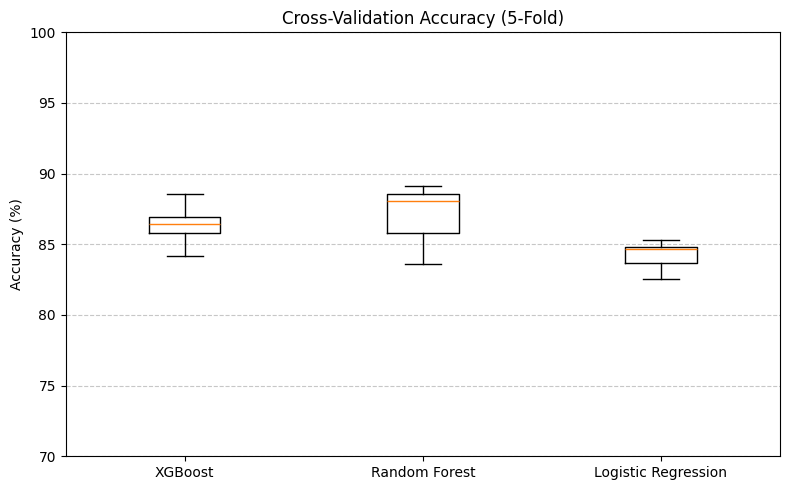

In [11]:
# Create a box plot to visualize the distribution of cross-validation scores
# Figure size: 8 inches wide by 5 inches tall
fig, ax = plt.subplots(figsize=(8, 5))

# Prepare data for box plot: list of accuracy arrays (convert proportions to percentages)
data = [cv_results['XGBoost']*100,
        cv_results['Random Forest']*100,
        cv_results['Logistic Regression']*100]

# Create the box plot with model names as x-axis tick_labels
ax.boxplot(data, tick_labels=['XGBoost', 'Random Forest', 'Logistic Regression'])
# Set plot title
ax.set_title('Cross-Validation Accuracy (5-Fold)')
# Label y-axis
ax.set_ylabel('Accuracy (%)')
# Set y-axis limits from 70% to 100%
#  to focus on relevant range
ax.set_ylim(70, 100)
# Add horizontal grid lines for easier reading of bar heights
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust layout to prevent label clipping
plt.tight_layout()
# Display the plot
plt.show()

---
## 3. ROC Curve + AUC Score

**What is ROC/AUC?**
- ROC = Receiver Operating Characteristic curve
- AUC = Area Under the Curve (score from 0.5 to 1.0)
- Measures how well the model separates disease from no-disease

**How to read AUC:**
- 1.0 = perfect model
- 0.9+ = excellent
- 0.8-0.9 = good
- 0.7-0.8 = fair
- 0.5 = random guessing (useless)

**Why it matters for medicine:**
- AUC is the standard metric in medical ML research
- Works well even with imbalanced datasets
- Shows performance at ALL possible thresholds, not just one

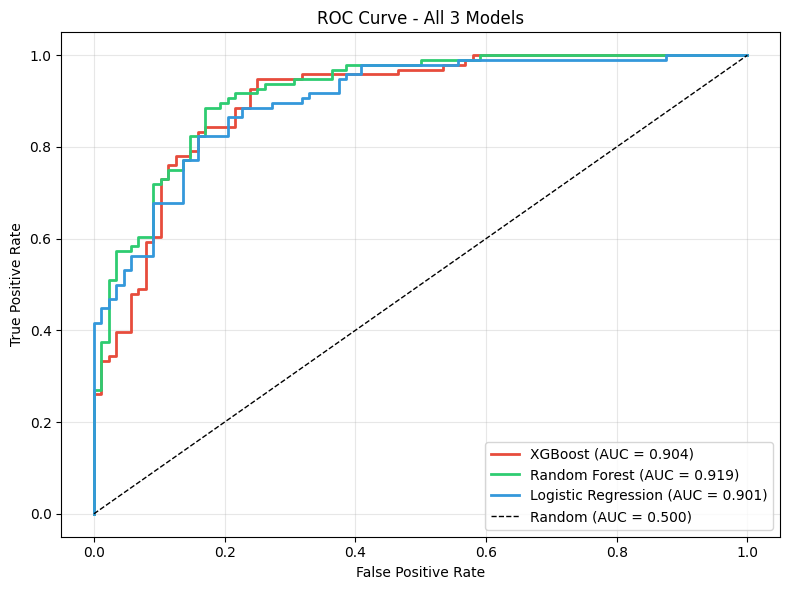


AUC Scores:
  XGBoost: 0.904
  Random Forest: 0.919
  Logistic Regression: 0.901


In [12]:
# Create a new figure for the ROC curve plot
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors for each model (consistent across plots)
colors = ['#e74c3c', '#2ecc71', '#3498db']
# Dictionary to store AUC scores for later comparison table
auc_scores = {}

# Loop through models and corresponding colors simultaneously
for (name, model), color in zip(models.items(), colors):
    # Get predicted probabilities for the positive class (disease) on the test set
    # predict_proba returns an array of shape (n_samples, 2) -> [prob_class0, prob_class1]
    # [:, 1] selects the second column (probability of class 1 = having disease)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC curve: false positive rate (FPR) and true positive rate (TPR) at various thresholds
    # roc_curve returns fpr, tpr, and thresholds (ignored with underscore)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    # Calculate Area Under the ROC Curve (AUC)
    # AUC = 1.0 is perfect discrimination; 0.5 is random guessing
    roc_auc = auc(fpr, tpr)
    # Store AUC score for this model
    auc_scores[name] = roc_auc
    
    # Plot the ROC curve for this model with a label showing AUC value
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

# Add diagonal dashed line representing a random classifier (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')

# Label axes: FPR = false alarm rate, TPR = sensitivity/recall
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - All 3 Models')
# Place legend in lower right corner
ax.legend(loc='lower right')
# Add light grid for readability
ax.grid(alpha=0.3)
# Adjust layout and display
plt.tight_layout()
plt.show()

# Print AUC scores for each model
print("\nAUC Scores:")
for name, score in auc_scores.items():
    print(f"  {name}: {score:.3f}")

---
## 4. Precision/Recall Curve

**What is Precision/Recall?**
- Precision = of all patients predicted as disease, how many actually have it?
- Recall = of all patients who actually have disease, how many did we catch?

**Why it matters for medical data:**
- Missing a sick patient (low recall) is more dangerous than a false alarm (low precision)
- This curve shows the trade-off between catching all sick patients vs false alarms
- AP (Average Precision) = summary score, higher = better

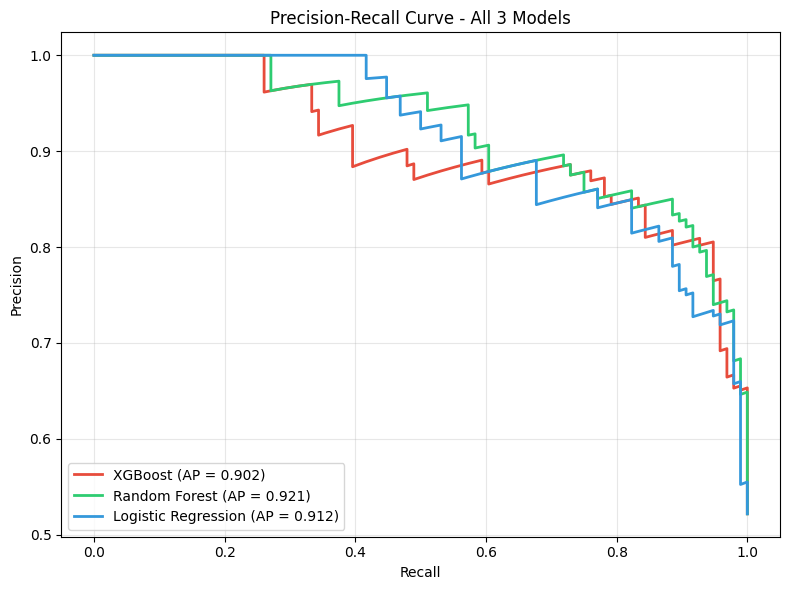


Average Precision Scores:
  XGBoost: 0.902
  Random Forest: 0.921
  Logistic Regression: 0.912


In [13]:
# Create a new figure for the Precision-Recall curve plot
fig, ax = plt.subplots(figsize=(8, 6))

# Dictionary to store Average Precision (AP) scores
ap_scores = {}

# Loop through models with colors
for (name, model), color in zip(models.items(), colors):
    # Get predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Compute precision-recall pairs for different probability thresholds
    # precision_recall_curve returns precision, recall, and thresholds
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    
    # Calculate Average Precision (AP) which summarizes the PR curve
    # AP is the area under the precision-recall curve; higher = better trade-off
    ap = average_precision_score(y_test, y_prob)
    # Store AP score
    ap_scores[name] = ap
    
    # Plot the PR curve for this model
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{name} (AP = {ap:.3f})')

# Label axes: Recall = Sensitivity (how many actual positives were found)
# Precision = Positive Predictive Value (how many predicted positives were correct)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - All 3 Models')
# Place legend in lower left corner (typical for PR curves)
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print Average Precision scores for each model
print("\nAverage Precision Scores:")
for name, score in ap_scores.items():
    print(f"  {name}: {score:.3f}")

---
## 5. Final Comparison Table

All 3 models compared across every metric.

In [14]:
# Print a header for the final comparison table
print("=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)
# Print column headers with fixed widths for alignment
print(f"{'Model':<22} {'Accuracy':>9} {'CV Avg':>9} {'CV Std':>9} {'AUC':>9} {'Avg Prec':>9}")
print("-" * 75)

# Loop through each model to populate the comparison table
for name, model in models.items():
    # Get predictions on the test set (hard class predictions, 0 or 1)
    pred = model.predict(X_test)
    # Calculate accuracy on the test set
    acc  = accuracy_score(y_test, pred)
    # Retrieve cross-validation scores array for this model
    cv   = cv_results[name]
    # Retrieve AUC score
    roc  = auc_scores[name]
    # Retrieve Average Precision score
    ap   = ap_scores[name]
    
    # Print one row with all metrics formatted
    # acc*100 converts proportion to percentage; cv.mean()*100 gives average CV accuracy %
    # cv.std()*100 shows variation as percentage
    print(f"{name:<22} {acc*100:>8.1f}% {cv.mean()*100:>8.1f}% {cv.std()*100:>8.1f}% {roc:>9.3f} {ap:>9.3f}")

print("=" * 75)
# Provide a quick guide to interpreting the columns
print("\nColumn guide:")
print("  Accuracy  = % correct on 184 test patients")
print("  CV Avg    = average accuracy across 5 cross-validation folds")
print("  CV Std    = consistency (lower = more consistent)")
print("  AUC       = area under ROC curve (1.0 = perfect, 0.5 = random)")
print("  Avg Prec  = average precision score (higher = better)")

FINAL MODEL COMPARISON
Model                   Accuracy    CV Avg    CV Std       AUC  Avg Prec
---------------------------------------------------------------------------
XGBoost                    83.7%     86.4%      1.4%     0.904     0.902
Random Forest              85.3%     87.0%      2.1%     0.919     0.921
Logistic Regression        82.6%     84.2%      1.0%     0.901     0.912

Column guide:
  Accuracy  = % correct on 184 test patients
  CV Avg    = average accuracy across 5 cross-validation folds
  CV Std    = consistency (lower = more consistent)
  AUC       = area under ROC curve (1.0 = perfect, 0.5 = random)
  Avg Prec  = average precision score (higher = better)


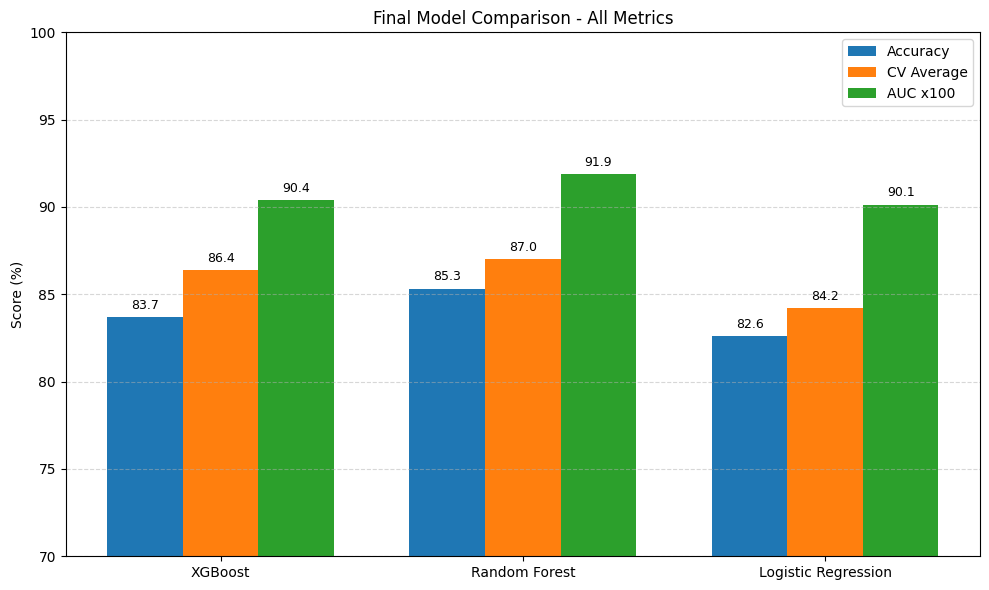

In [15]:
# Create a bar chart to visually compare the three models across key metrics
model_names = list(models.keys())
# Compute metric values for each model (as percentages for consistency)
metrics = {
    'Accuracy': [accuracy_score(y_test, m.predict(X_test))*100 for m in models.values()],
    'CV Average': [cv_results[n].mean()*100 for n in model_names],
    'AUC x100':  [auc_scores[n]*100 for n in model_names]
}

# Set up x-axis positions for grouped bars
x = np.arange(len(model_names))  # [0, 1, 2] positions for the three model names
width = 0.25  # width of each bar

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Loop through metrics and plot grouped bars
for i, (metric, values) in enumerate(metrics.items()):
    # Position bars for this metric: shift by i * width
    bars = ax.bar(x + i*width, values, width, label=metric)
    # Add numeric labels on top of each bar for precise reading
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Label y-axis and title
ax.set_ylabel('Score (%)')
ax.set_title('Final Model Comparison - All Metrics')
# Set x-ticks to be centered under the group of three bars
ax.set_xticks(x + width)
ax.set_xticklabels(model_names)
# Limit y-axis to 70-100% range for better visual discrimination
ax.set_ylim(70, 100)
# Show legend to identify which color corresponds to which metric
ax.legend()
# Add horizontal grid lines
ax.grid(axis='y', linestyle='--', alpha=0.5)
# Adjust layout and display
plt.tight_layout()
plt.show()

---
## Summary

**Validation methods used:**
- ✅ Train/Test Split (184 unseen patients)
- ✅ 5-Fold Cross-Validation (confirms consistency)
- ✅ ROC Curve + AUC Score (medical standard metric)
- ✅ Precision/Recall Curve (important for medical data)

**Conclusion:**
All 3 models were validated using multiple rigorous methods. The results confirm the integrity and reliability of the models for heart disease prediction.